# 02 — Preprocessing

Loads raw data, handles missing values, and performs a chronological train/test split.

**Input:** `data/raw/<TICKER>_<START>_<END>_<INTERVAL>.csv`  
**Output:** `data/processed/<TICKER>_train.csv` and `data/processed/<TICKER>_test.csv`

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Parameters

Must match the values used in `01_data_acquisition.ipynb`.

In [8]:
TICKER   = 'AAPL'
START    = '2020-01-01'
END      = '2025-12-31'
INTERVAL = '1d'

TRAIN_RATIO = 0.8  # 80% train, 20% test

## Load Raw Data

In [9]:
input_path = f'../data/raw/{TICKER}_{START}_{END}_{INTERVAL}.csv'
df = pd.read_csv(input_path, index_col='Date', parse_dates=True)

print(f"Loaded {len(df)} rows from {input_path}")
df.head()

Loaded 1507 rows from ../data/raw/AAPL_2020-01-01_2025-12-31_1d.csv


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928024,72.533064,71.708665,72.277548,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


## Handle Missing Values

In [10]:
print("Missing values before:")
print(df.isnull().sum())

# Forward fill to handle gaps (e.g. holidays where market was closed)
df = df.ffill()

print("\nMissing values after:")
print(df.isnull().sum())

Missing values before:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Missing values after:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


## Chronological Train/Test Split

We split by time, not randomly, to respect the temporal structure of the series and avoid data leakage.

In [11]:
split_idx = int(len(df) * TRAIN_RATIO)

train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

print(f"Train: {len(train)} rows ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Test:  {len(test)} rows ({test.index[0].date()} to {test.index[-1].date()})")

Train: 1205 rows (2020-01-02 to 2024-10-15)
Test:  302 rows (2024-10-16 to 2025-12-30)


## Visualize Split

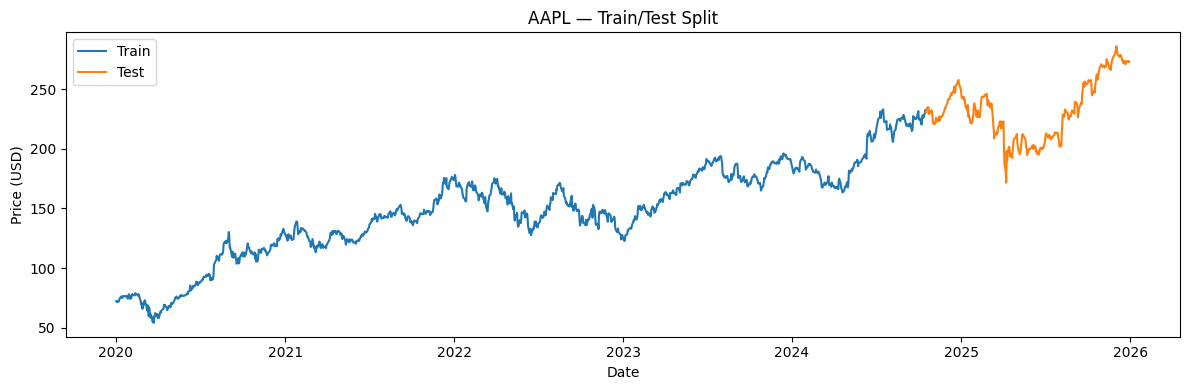

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train.index, train['Close'], label='Train')
ax.plot(test.index, test['Close'], label='Test')
ax.set_title(f'{TICKER} — Train/Test Split')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

## Save Processed Data

In [13]:
os.makedirs('../data/processed', exist_ok=True)

train_path = f'../data/processed/{TICKER}_train.csv'
test_path  = f'../data/processed/{TICKER}_test.csv'

train.to_csv(train_path)
test.to_csv(test_path)

print(f"Saved train to {train_path}")
print(f"Saved test  to {test_path}")

Saved train to ../data/processed/AAPL_train.csv
Saved test  to ../data/processed/AAPL_test.csv
